# Simple Plotting Examples

Matplotlib is a data visualization library for creating static, animated and interactive figures. Pyplot is the interface that we use to conveniently access the library.

## Setup

Import the Matplotlib module `pyplot` only once at the beginning of your code. It is commonly imported as `plt` to reduce the amount of typing.

In [1]:
# | code-fold: false
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp


# For nice plots
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

In [2]:
#| echo: false
plt.style.use('seaborn-v0_8-whitegrid') 
# plt.rcParams['figure.dpi'] = 150 

# Force Matplotlib to create an SVG without fixed width/height
# import matplotlib
# matplotlib.rcParams['svg.fonttype'] = 'none' # Makes text selectable/crisp

%config InlineBackend.figure_format = 'svg'

## Matplotlib Styling - The Simple Way

There are multiple ways to style plots in Matplotlib. The simplest approach for a clean white background with grid is:

1. **Default style + grid** (simplest):
   ```python
   plt.grid(True, alpha=0.3)
   ```

2. **Using built-in styles**:
   ```python
   plt.style.use('seaborn-v0_8-whitegrid')   # White background with grid
   plt.style.use('ggplot')                   # R's ggplot style
   plt.style.use('bmh')                      # Bayesian Methods for Hackers style
   ```

3. **Set style once for all plots**:
   ```python
   plt.rcParams['axes.grid'] = True
   plt.rcParams['grid.alpha'] = 0.3
   ```

For these examples, we'll use the simplest approach when needed.

## Example: Plotting Discrete Points

The simplest type of plot - showing discrete data points.

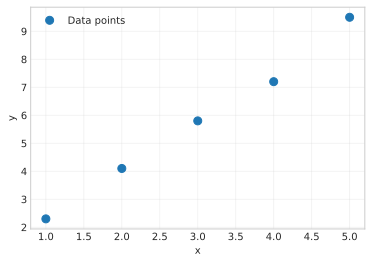

In [ ]:
#| classes: size-80

# Data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.3, 4.1, 5.8, 7.2, 9.5])

# Simple plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o', markersize=8, label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### A Note on Figure Size

You may notice that changing `figsize` does not alter the plot's visible size within a notebook, yet it affects the relative size of text and markers. This behavior occurs because the notebook environment scales the rendered image to fit a fixed output area.

The `figsize=(width, height)` parameter sets the intended *physical size* of the figure in inches. This physical size, combined with the resolution (set by `dpi`, or dots-per-inch), determines the final pixel dimensions of the image Matplotlib creates. For example, a figure with `figsize=(12, 8)` is rendered on a canvas twice as large as one with `figsize=(6, 4)`.

Plot elements like font and marker sizes are defined in absolute units (points). Consequently, on the larger canvas, these elements occupy a smaller fraction of the total area. When the notebook scales both rendered images down to fit the same on-screen space, the text and markers from the larger figure appear smaller, giving the plot more "room to breathe."

In practice, we use `figsize` primarily to control a plot's *aspect ratio*, e.g., creating a square plot with `figsize=(6, 6)`. It also allows us to adjust visual density. The `figsize` and `dpi` settings are most critical when saving a figure with `plt.savefig()`, as they directly control the output file's dimensions and print quality.

## Example: Plotting SymPy Functions 

When we work with symbolic mathematics in SymPy, we often need to visualize the resulting expressions. However, Matplotlib cannot directly plot symbolic expressions because it operates on numerical arrays. We must first convert the symbolic function into a numerical function that can evaluate many points efficiently.

The standard workflow involves three steps: defining the symbolic expression, converting it to a numerical function using `lambdify()`, and then evaluating it over an array of numerical values. Let us demonstrate this process by plotting the sine function.

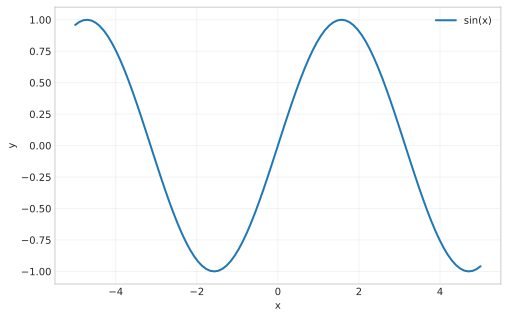

In [ ]:
#| classes: size-80
# Define symbolic variable and expression
x = sp.Symbol('x')
f = sp.sin(x)

# Convert symbolic expression to numerical function
f_num = sp.lambdify(x, f, 'numpy')

# Create array of x values
x_vals = np.linspace(-5, 5, 100)

# Evaluate the function at these points
y_vals = f_num(x_vals)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, linewidth=2, label='sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The `lambdify()` function translates SymPy's symbolic representation into a standard Python function that uses NumPy for numerical computation. This is necessary because SymPy expressions are designed for symbolic manipulation (differentiation, integration, simplification) rather than numerical evaluation. The name "lambdify" comes from Python's lambda functions, though the result is actually a regular function optimized for array operations.

By specifying `'numpy'` as the third argument, we ensure that the generated function can handle NumPy arrays efficiently. When we pass the array `x_vals` to `f_num()`, it evaluates the sine function at all 100 points simultaneously using vectorized operations, which is much faster than evaluating each point individually in a loop.

This workflow becomes repetitive when we need to plot many functions. For each new expression, we must remember to create the numerical function, generate the array of evaluation points, compute the values, and then plot. Let us now examine a more convenient approach.

## Example: Plotting SymPy Functions with MechanicsKit's fplot

The repetitive nature of the lambdify workflow motivates the creation of a higher-level plotting function. MechanicsKit provides `fplot()`, which automates the entire process we demonstrated above. The function takes a symbolic expression and directly creates a plot, handling the conversion to numerical form, array generation, evaluation, and plotting internally.

We import `fplot` from MechanicsKit and use it to plot the same sine function. Observe how much simpler the code becomes.

In [5]:
# | code-fold: false
from mechanicskit import fplot

### When to Use Each Approach

Both methods produce identical plots, but they serve different purposes in your workflow.

**Use the traditional lambdify approach** when you need the numerical function for other purposes beyond plotting. For instance, if you plan to integrate the function numerically, pass it to an optimization routine, or perform repeated evaluations with different parameter values, creating the numerical function explicitly makes sense. The lambdified function can be reused efficiently without repeated conversion overhead.

**Use fplot** when your primary goal is visualization. The function is particularly useful in interactive sessions, educational demonstrations, and when exploring the behavior of symbolic expressions. Since the entire plotting pipeline is automated, you can quickly visualize expressions without the cognitive overhead of managing arrays and evaluation. This makes it ideal for the type of rapid prototyping and exploration common in mechanics courses.

Throughout the remaining examples, we use `fplot` whenever we plot symbolic expressions, reserving the traditional approach for cases where we need explicit control over the numerical evaluation process.

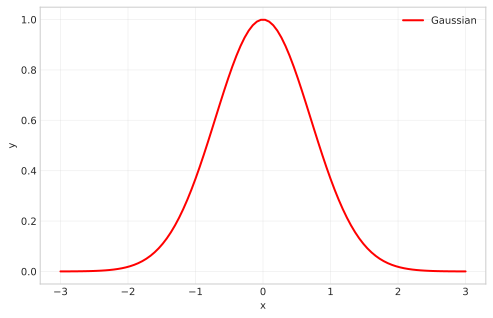

In [ ]:
#| classes: size-80
# Plot Gaussian with custom range and styling
plt.figure(figsize=(8, 5))
fplot(sp.exp(-x**2), range=(-3, 3), color='red', linewidth=2, label='Gaussian')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Comparing the Two Approaches

Notice the difference in code complexity. The traditional approach required five explicit steps:

```python
f_num = sp.lambdify(x, f, 'numpy')  # Step 1: Convert to numerical function
x_vals = np.linspace(-5, 5, 100)     # Step 2: Create array of x values
y_vals = f_num(x_vals)                # Step 3: Evaluate function
plt.plot(x_vals, y_vals)              # Step 4: Plot the results
```

The `fplot` approach reduces this to a single function call:

```python
fplot(sp.sin(x))  # All steps handled internally
```

The function automatically detects that `x` is the independent variable, creates an appropriate range of values (defaulting to [-5, 5]), evaluates the expression, and plots the result. This is similar to MATLAB's `fplot` function, which provides the same convenience for symbolic mathematics.

We can customize the range and styling by passing additional arguments. Let us plot a Gaussian function over a specific range.

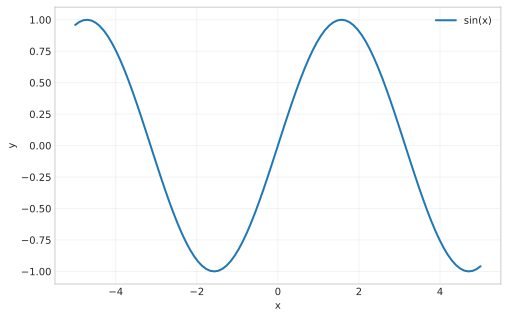

In [ ]:
#| classes: size-80
# Import fplot from MechanicsKit
from mechanicskit import fplot

# Plot sin(x) with automatic parameter detection and default range [-5, 5]
plt.figure(figsize=(8, 5))
fplot(sp.sin(x), linewidth=2, label='sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Example: Data Fitting and Plotting Combined

Based on the solar car acceleration example from [Particle Kinematics](https://mechanics.ju.se/ParticleKinematics.html#example-2---data-fitting).

This example shows:

- Plotting discrete measurement data
- Fitting a polynomial using SymPy
- Plotting the fitted continuous function
- Computing and plotting derivatives

Fitted velocity: v(t) = -0.309736757594532*t**2 + 7.75454224391216*t + 1.05549793621097
Acceleration: a(t) = 7.75454224391216 - 0.619473515189064*t


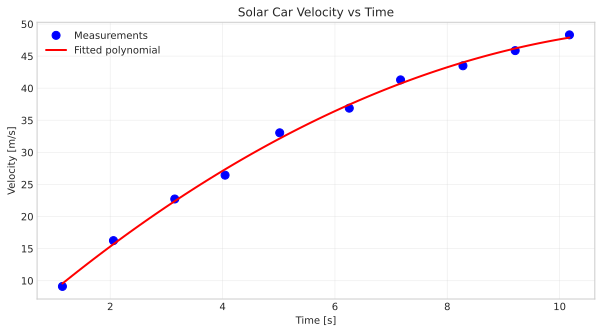

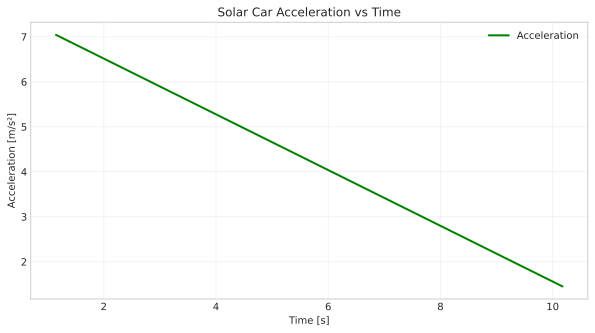

In [ ]:
#| classes: size-80
# Solar car velocity measurements
T = np.array([1.1486, 2.0569, 3.1485, 4.0443, 5.0165, 6.2552, 7.1682, 8.2789, 9.209, 10.175])
V = np.array([9.1023, 16.245, 22.732, 26.446, 33.052, 36.889, 41.304, 43.496, 45.861, 48.319])

# Fit quadratic polynomial using NumPy
coeffs = np.polyfit(T, V, 2)

# Create symbolic expression
t = sp.Symbol('t')
v_fit = coeffs[0]*t**2 + coeffs[1]*t + coeffs[2]
a_fit = sp.diff(v_fit, t)  # Acceleration (derivative of velocity)

print(f"Fitted velocity: v(t) = {v_fit}")
print(f"Acceleration: a(t) = {a_fit}")

# Plot velocity: data + fitted curve
plt.figure(figsize=(10, 5))

# Measured data
plt.plot(T, V, 'o', markersize=8, label='Measurements', color='blue')

# Fitted curve using fplot
fplot(v_fit, range=(T.min(), T.max()), color='red', linewidth=2, label='Fitted polynomial')

plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.title('Solar Car Velocity vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot acceleration
plt.figure(figsize=(10, 5))
fplot(a_fit, range=(T.min(), T.max()), color='green', linewidth=2, label='Acceleration')
plt.xlabel('Time [s]')
plt.ylabel('Acceleration [m/s²]')
plt.title('Solar Car Acceleration vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Example: Parametric Curves

Parametric curves are particularly useful for visualizing trajectories, circular motion, and other phenomena where position depends on a parameter such as time. The `fplot` function handles parametric curves naturally by accepting two expressions corresponding to x(t) and y(t) coordinates.

Note that when specifying the `range` parameter, we use `np.pi` (NumPy's numerical constant) rather than `sp.pi` (SymPy's symbolic constant). The range must contain numerical values that can be used by NumPy's `linspace` function to generate the evaluation points.

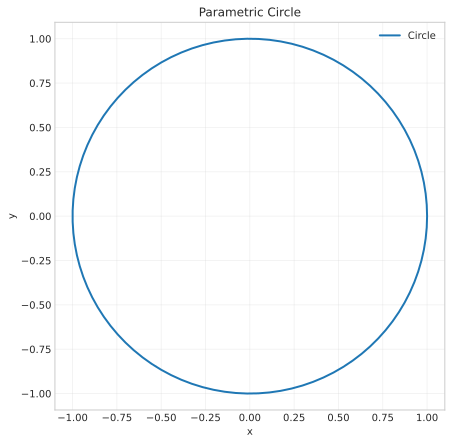

In [ ]:
#| classes: size-80
# Define parameter
t = sp.Symbol('t')

# Circle: x(t) = cos(t), y(t) = sin(t)
plt.figure(figsize=(7, 7))
fplot(sp.cos(t), sp.sin(t), range=(0, 2*np.pi), linewidth=2, label='Circle')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')  # Equal aspect ratio
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Parametric Circle')
plt.show()


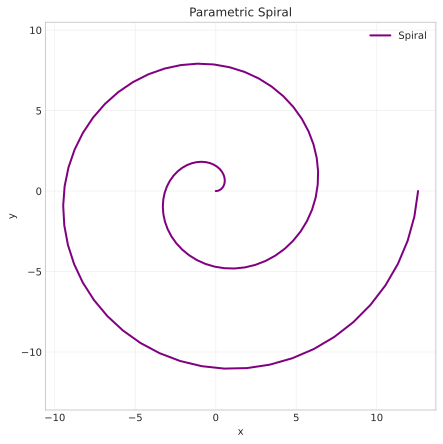

In [ ]:
#| classes: size-80
# Spiral: x(t) = t*cos(t), y(t) = t*sin(t)
plt.figure(figsize=(7, 7))
fplot(t*sp.cos(t), t*sp.sin(t), range=(0, 4*np.pi), linewidth=2, color='purple', label='Spiral')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Parametric Spiral')
plt.show()

## Example: Multiple Functions on Same Axes

Comparing multiple functions on the same plot reveals relationships and patterns that might not be obvious when viewing them separately. We simply call `fplot` multiple times, with each call adding another curve to the current axes.

## Example: 2D Vector Plots


We begin by defining some new numerical vectors that can be used for the following examples. They can easily be replaced by your own symbolic vectors using the methodology described in the `SymPy` and `NumPy` sections above:

In [11]:
theta = np.pi/3 # slider variable here for example!
rr_OA = 0.5 * np.array([np.cos(theta), np.sin(theta), 0])
rr_OB = 0.9 * np.array([np.sin(theta), np.cos(theta), 0])
rr_O = np.array([0, 0, 0])

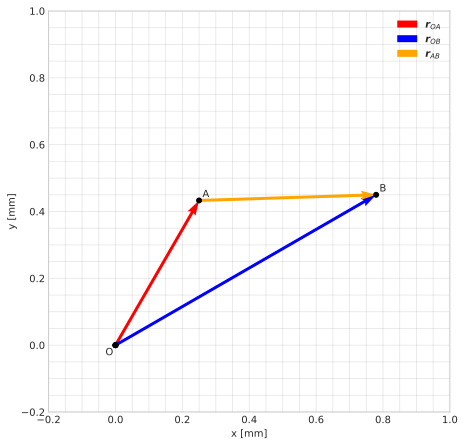

In [ ]:
#| classes: size-80
# 2D figure settings
plt.style.use('seaborn-v0_8-whitegrid')
fig2 = plt.figure(figsize=(7.25, 7.25))
ax2 = fig2.add_subplot()
ax2.set_aspect('equal')
ax2.set(xlim=[-0.2, 1.0], ylim=[-0.2, 1.0], xlabel='x [mm]', ylabel='y [mm]')
plt.grid(True, which='both', color='k', linestyle='-', alpha=0.1)
plt.minorticks_on()

# draw quivers
ax2.quiver(*rr_O[:-1], *rr_OA[:-1], 
           color='red', scale=1.2, label='$\\boldsymbol{r}_{OA}$')
ax2.quiver(*rr_O[:-1], *rr_OB[:-1], 
           color='blue', scale=1.2, label='$\\boldsymbol{r}_{OB}$')
ax2.quiver(*rr_OA[:-1], *(rr_OB[:-1]-rr_OA[:-1]),
           color='orange', scale=1.2, label='$\\boldsymbol{r}_{AB}$')

# if you dislike quiver(), you can draw lines using plot() and zip() instead
# ax2.plot(*zip(rr_O[:-1], rr_OA[:-1]), 
#          color='red', linewidth=2.5, label='$\\boldsymbol{r}_{OA}$')
# ax2.plot(*zip(rr_O[:-1], rr_OB[:-1]), 
#          color='blue', linewidth=2.5, label='$\\boldsymbol{r}_{OB}$')
# ax2.plot(*zip(rr_OB[:-1], rr_OA[:-1]), 
#          color='orange', linewidth=2.5, label='$\\boldsymbol{r}_{AB}$')

# draw points
ax2.plot(*rr_O, marker='o', color='black', markersize=5, zorder=10)
ax2.plot(*rr_OA, marker='o', color='black', markersize=5, zorder=10)
ax2.plot(*rr_OB, marker='o', color='black', markersize=5, zorder=10)

# draw point labels
ax2.text(*rr_O[:-1]-0.03, 'O') # - small adjustment
ax2.text(*rr_OA[:-1]+0.01, 'A') # + small adjustment
ax2.text(*rr_OB[:-1]+0.01, 'B') # + small adjustment

# draw legend
ax2.legend()

## Example: 3D Vector Plots

3D works in the same way as 2D, with the exception of the `add_subplot()` line that now also specifies the projection type as `3d`. The `view_init()` command is used to rotate the camera view. 

Note also that no slicing is required in 3D, since the vectors already have the correct "shape". To make the arrow-heads look proportional in 3D, the parameter `arrow_length_ratio` is set manually, as the arrowhead size automatically scales up with the vector norm as well as the choice of xlim, ylim and zlim.

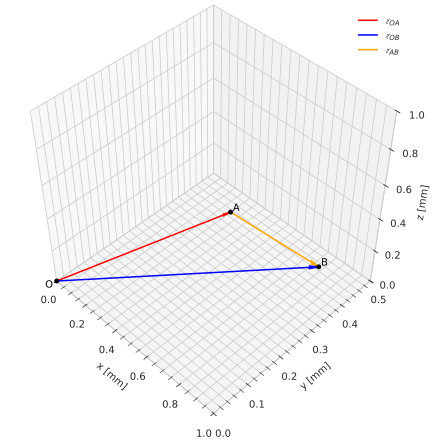

In [ ]:
#| classes: size-80
# 3D figure settings
plt.style.use('seaborn-v0_8-whitegrid')
fig3 = plt.figure(figsize=(7.25, 7.25))
ax3 = fig3.add_subplot(projection='3d')
ax3.view_init(elev=45, azim=-45)
ax3.set_proj_type('persp', focal_length=0.5) # or 'ortho' without focal_length
ax3.set_aspect('equal')
ax3.set(xlim=[0.0, 1.0], ylim=[0.0, 0.5], zlim=[0.0, 1.0], 
       xlabel='x [mm]', ylabel='y [mm]', zlabel='z [mm]')
plt.minorticks_on()

# draw quivers
ax3.quiver(*rr_O, *rr_OA, linewidth=1.5, 
           color='red', arrow_length_ratio=0.05, label='$\\mathbb{r}_{OA}$')
ax3.quiver(*rr_O, *rr_OB, linewidth=1.5, 
           color='blue', arrow_length_ratio=0.04, label='$\\mathbb{r}_{OB}$')
ax3.quiver(*rr_OA, *(rr_OB-rr_OA), linewidth=1.5, 
           color='orange', arrow_length_ratio=0.09, label='$\\mathbb{r}_{AB}$')

# # if you dislike quiver(), you can draw lines using plot() and zip() instead
# ax3.plot(*zip(rr_O, rr_OA), 
#          color='red', linewidth=2.5, label='$\\mathbb{r}_{OA}$')
# ax3.plot(*zip(rr_O, rr_OB), 
#          color='blue', linewidth=2.5, label='$\\mathbb{r}_{OB}$')
# ax3.plot(*zip(rr_OB, rr_OA), 
#          color='orange', linewidth=2.5,label='$\\mathbb{r}_{AB}$')

# draw points
ax3.plot(*rr_O, marker='o', color='black', markersize=4, zorder=9)
ax3.plot(*rr_OA, marker='o', color='black', markersize=4, zorder=9)
ax3.plot(*rr_OB, marker='o', color='black', markersize=4, zorder=9)

# draw point labels
ax3.text(*rr_O-0.025, 'O', fontsize=10, color='black', zorder=10)
ax3.text(*rr_OA+0.005, 'A', fontsize=10, color='black', zorder=10)
ax3.text(*rr_OB+0.005, 'B', fontsize=10, color='black', zorder=10)

# draw legend
ax3.legend()

## Example: Surface Plot with Two Parameters

For functions of two variables, we must use the traditional lambdify approach since `fplot` is designed for functions of a single parameter. Three-dimensional surface plots and their two-dimensional contour counterparts reveal how a function varies across a plane.

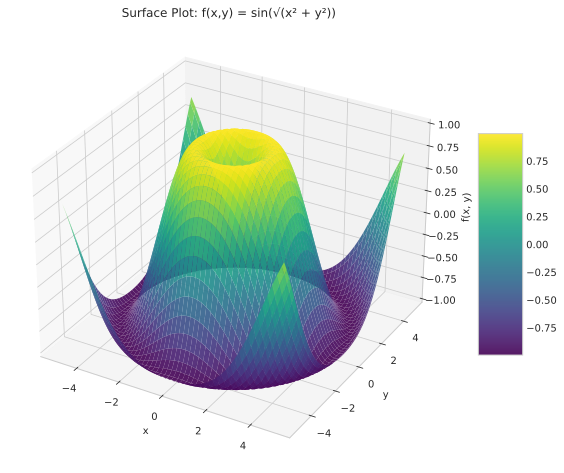

In [ ]:
#| classes: size-80
# Define symbolic function of two variables
x, y = sp.symbols('x y')
f = sp.sin(sp.sqrt(x**2 + y**2))  # Ripple function

# Convert to numerical function
f_num = sp.lambdify([x, y], f, 'numpy')

# Create mesh grid
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_num(X, Y)

# Create 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Surface Plot: f(x,y) = sin(√(x² + y²))')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()


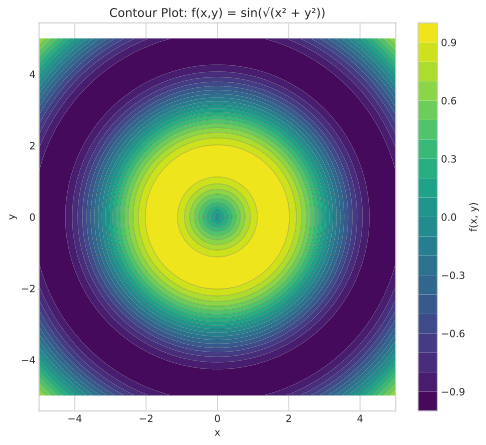

In [ ]:
#| classes: size-80
# Contour plot (2D view)
plt.figure(figsize=(8, 7))
contour = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(contour, label='f(x, y)')
plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot: f(x,y) = sin(√(x² + y²))')
plt.axis('equal')
plt.show()

## More examples

More examples can be found in the [MechanicsKit documentation](../MechanicsKitDocs/examples_fplot.ipynb).